# Home Credit Default Risk Predictor
## 02 – Exploratory Data Analysis (Train Set Only)

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

train = pd.read_csv('application_train.csv')
print(f'Shape: {train.shape[0]:,} rows x {train.shape[1]} columns')

Shape: 307,511 rows x 23 columns


In [2]:
# Identify feature types
target_col = 'TARGET'
numerical_features = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                      'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
categorical_features = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                         'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                         'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE',
                         'ORGANIZATION_TYPE', 'NAME_HOUSING_TYPE']

---
### 1. Quick Overview

In [3]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,OCCUPATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,DAYS_EMPLOYED,ORGANIZATION_TYPE,NAME_HOUSING_TYPE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,Secondary / secondary special,Single / not married,Laborers,0.083037,0.262949,0.139376,-9461,-637,Business Entity Type 3,House / apartment
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,Higher education,Married,Core staff,0.311267,0.622246,NaN,-16765,-1188,School,House / apartment
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,Secondary / secondary special,Single / not married,Laborers,NaN,0.555912,0.729567,-19046,-225,Government,House / apartment
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,Secondary / secondary special,Civil marriage,Laborers,NaN,0.650442,NaN,-19005,-3039,Business Entity Type 3,House / apartment
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,Secondary / secondary special,Single / not married,Core staff,NaN,0.322738,NaN,-19932,-3038,Religion,House / apartment


In [4]:
train[numerical_features].describe().round(2)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,DAYS_EMPLOYED
count,307511.00,3.075110e+05,307511.00,307499.00,307233.00,134133.00,306851.00,246546.00,307511.00,307511.00
mean,0.42,1.687979e+05,599026.00,27108.57,538396.21,0.50,0.51,0.51,-16037.00,63815.05
std,0.72,2.371231e+05,402490.78,14493.74,369446.46,0.21,0.19,0.19,4363.99,141275.77
min,0.00,2.565000e+04,45000.00,1615.50,40500.00,0.01,0.00,0.00,-25229.00,-17912.00
25%,0.00,1.125000e+05,270000.00,16524.00,238500.00,0.33,0.39,0.37,-19682.00,-2760.00
50%,0.00,1.471500e+05,513531.00,24903.00,450000.00,0.51,0.57,0.54,-15750.00,-1213.00
75%,1.00,2.025000e+05,808650.00,34596.00,679500.00,0.68,0.66,0.67,-12413.00,-289.00
max,19.00,1.170000e+08,4050000.00,258025.50,4050000.00,0.96,0.85,0.90,-7489.00,365243.00


---
### 2. Missing Values

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing': missing,
    '% of Total': (missing / len(train) * 100).round(2)
})
print(missing_df)
print(f'\nColumns with missing data: {len(missing)} / {train.shape[1]}')

                 Missing  % of Total
EXT_SOURCE_1      173378       56.38
OCCUPATION_TYPE    96391       31.35
EXT_SOURCE_3       60965       19.83
NAME_TYPE_SUITE     1292        0.42
EXT_SOURCE_2         660        0.21
AMT_GOODS_PRICE      278        0.09
AMT_ANNUITY           12        0.00

Columns with missing data: 7 / 23


---
### 3. Target Variable (Class Imbalance)

0 (No default) : 282,686  (91.9%)
1 (Default)    :  24,825  (8.1%)


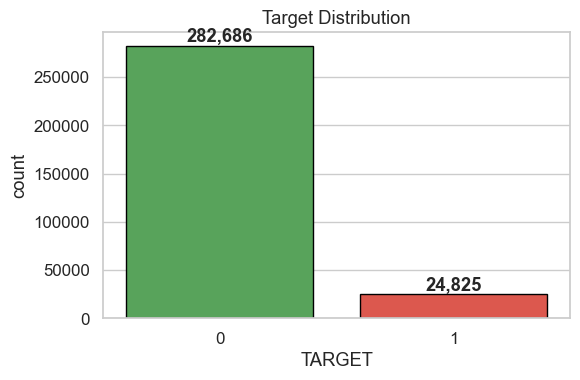

In [6]:
target_counts = train[target_col].value_counts()
target_pct = train[target_col].value_counts(normalize=True) * 100

print(f'0 (No default) : {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)')
print(f'1 (Default)    : {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=target_col, hue=target_col, data=train,
              palette={0: '#4CAF50', 1: '#F44336'},
              edgecolor='black', legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Distribution')
plt.tight_layout()
plt.show()

---
### 4. Numerical Features vs TARGET

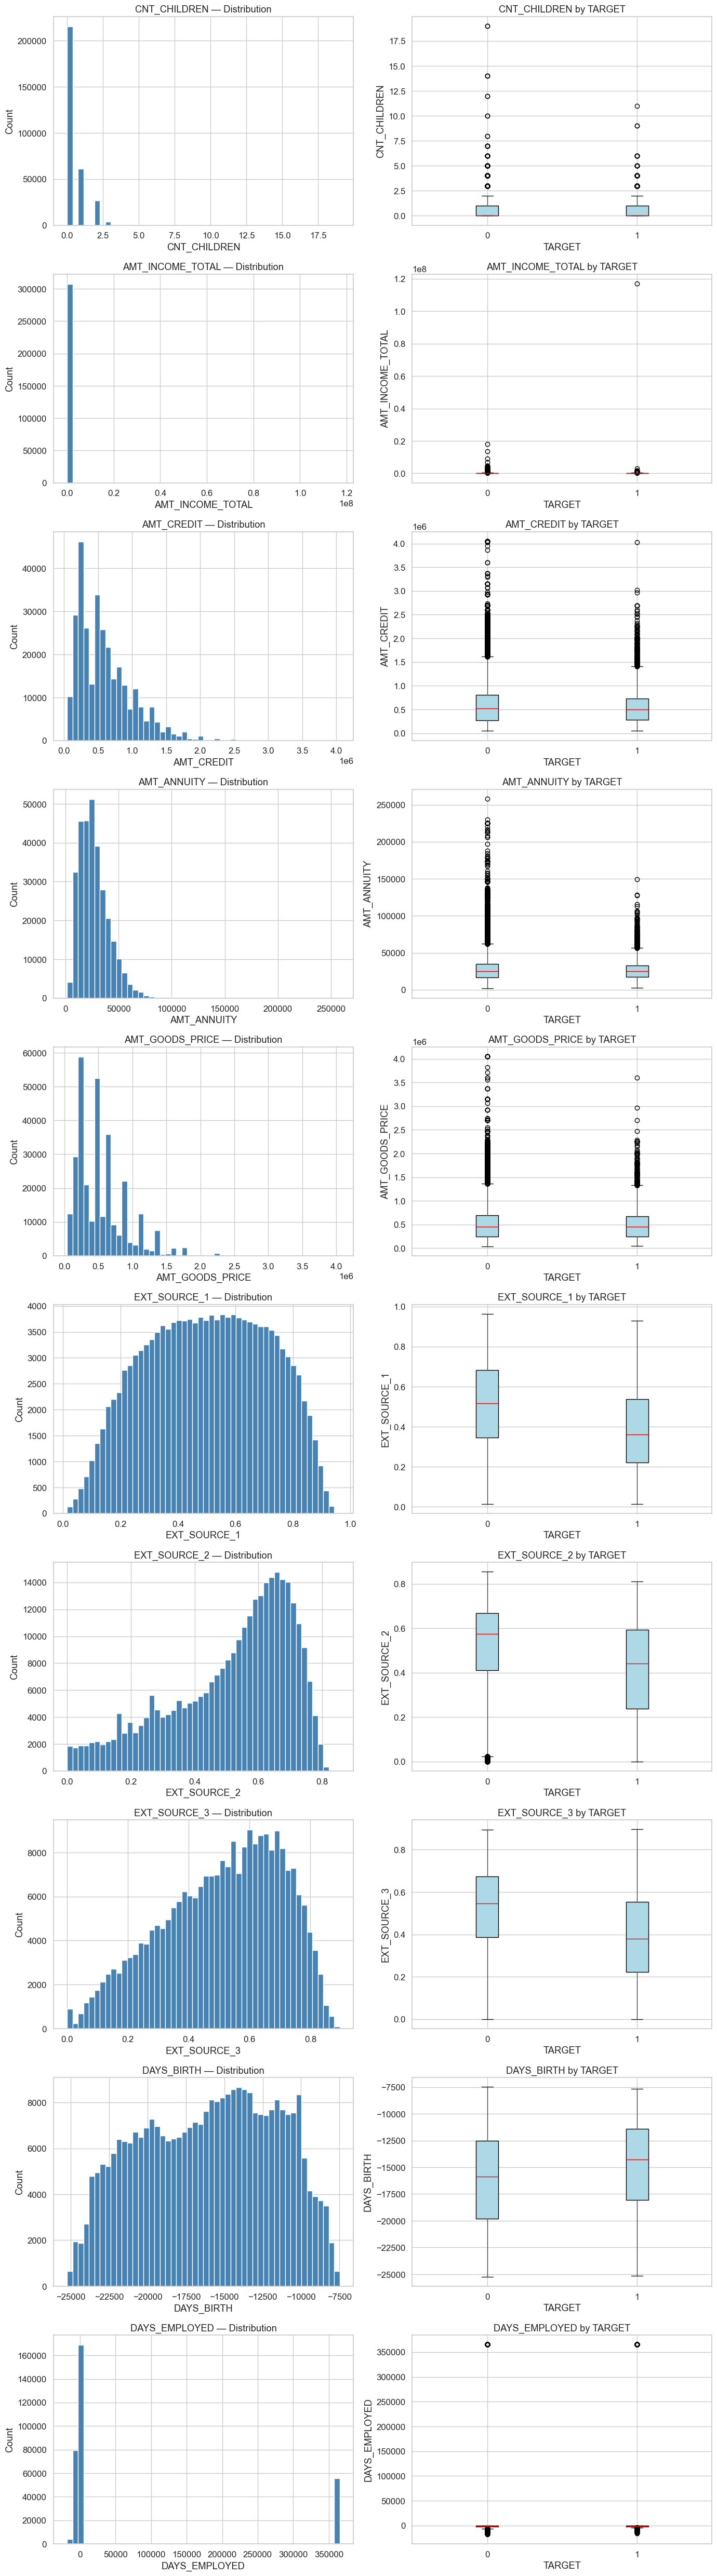

In [7]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(14, 5 * len(numerical_features)))

for i, feat in enumerate(numerical_features):
    # Distribution
    ax1 = axes[i, 0]
    train[feat].dropna().hist(bins=50, ax=ax1, color='steelblue', edgecolor='white')
    ax1.set_title(f'{feat} — Distribution')
    ax1.set_xlabel(feat)
    ax1.set_ylabel('Count')

    # Box plot by TARGET
    ax2 = axes[i, 1]
    train.boxplot(column=feat, by=target_col, ax=ax2,
                  patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red'))
    ax2.set_title(f'{feat} by TARGET')
    ax2.set_xlabel('TARGET')
    ax2.set_ylabel(feat)
    fig.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

---
### 5. DAYS_EMPLOYED Anomaly Analysis

Anomalous DAYS_EMPLOYED (365243): 55,374 rows (18.01%)

Default rate for anomalous group : 0.0540
Default rate for normal group    : 0.0866
Overall default rate             : 0.0807


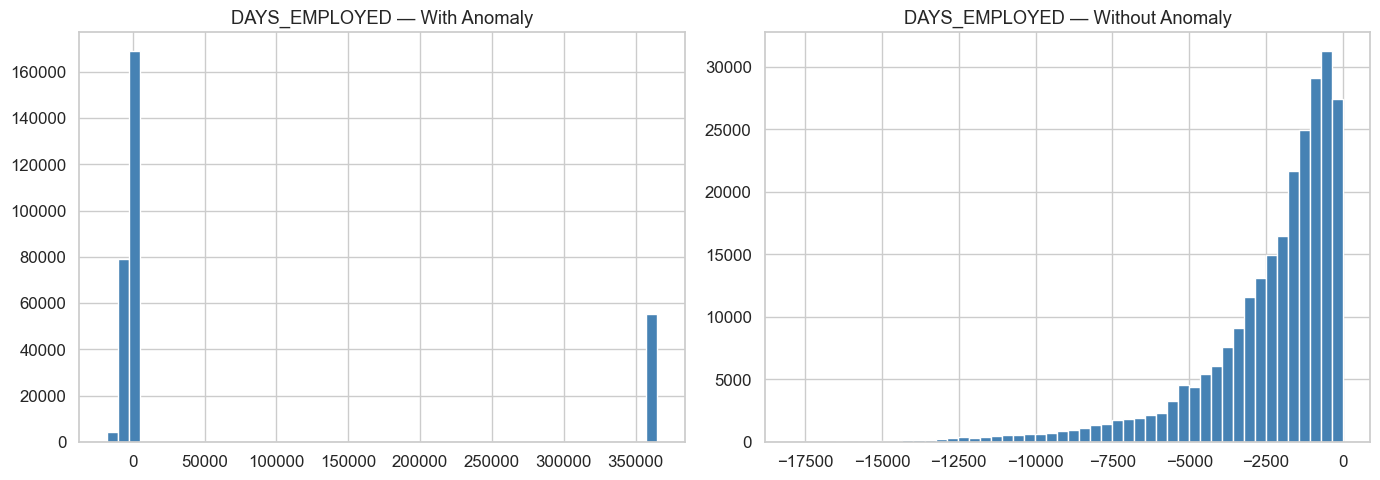

In [8]:
# The DAYS_EMPLOYED column has an anomalous value of 365243 for many rows
anomaly_mask = train['DAYS_EMPLOYED'] == 365243
anomaly_count = anomaly_mask.sum()

print(f'Anomalous DAYS_EMPLOYED (365243): {anomaly_count:,} rows ({anomaly_count/len(train)*100:.2f}%)')
print(f'\nDefault rate for anomalous group : {train.loc[anomaly_mask, "TARGET"].mean():.4f}')
print(f'Default rate for normal group    : {train.loc[~anomaly_mask, "TARGET"].mean():.4f}')
print(f'Overall default rate             : {train["TARGET"].mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# With anomaly
train['DAYS_EMPLOYED'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('DAYS_EMPLOYED — With Anomaly')

# Without anomaly
train.loc[~anomaly_mask, 'DAYS_EMPLOYED'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('DAYS_EMPLOYED — Without Anomaly')

plt.tight_layout()
plt.show()

---
### 6. Categorical Features vs TARGET

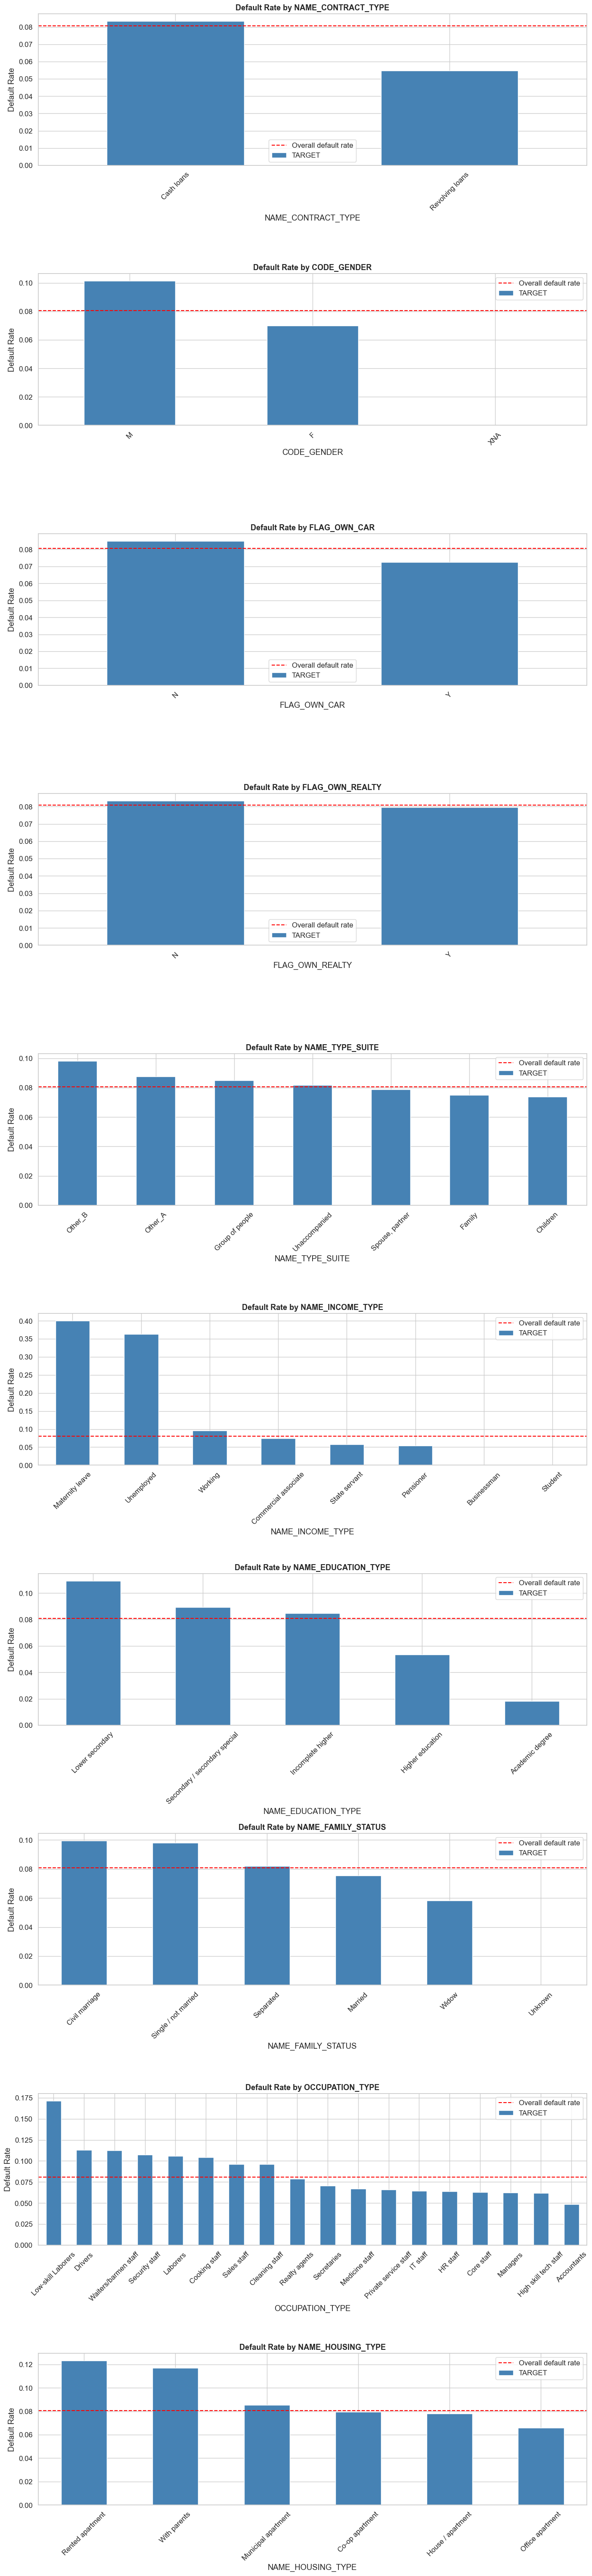

In [9]:
# Plot categorical features (excluding ORGANIZATION_TYPE which has too many categories)
cat_features_to_plot = [f for f in categorical_features if f != 'ORGANIZATION_TYPE']

fig, axes = plt.subplots(len(cat_features_to_plot), 1, figsize=(14, 6 * len(cat_features_to_plot)))

for i, feat in enumerate(cat_features_to_plot):
    ax = axes[i]
    # Calculate default rate per category
    cat_target = train.groupby(feat)[target_col].mean().sort_values(ascending=False)
    cat_target.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Default Rate by {feat}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.axhline(y=train[target_col].mean(), color='red', linestyle='--', label='Overall default rate')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

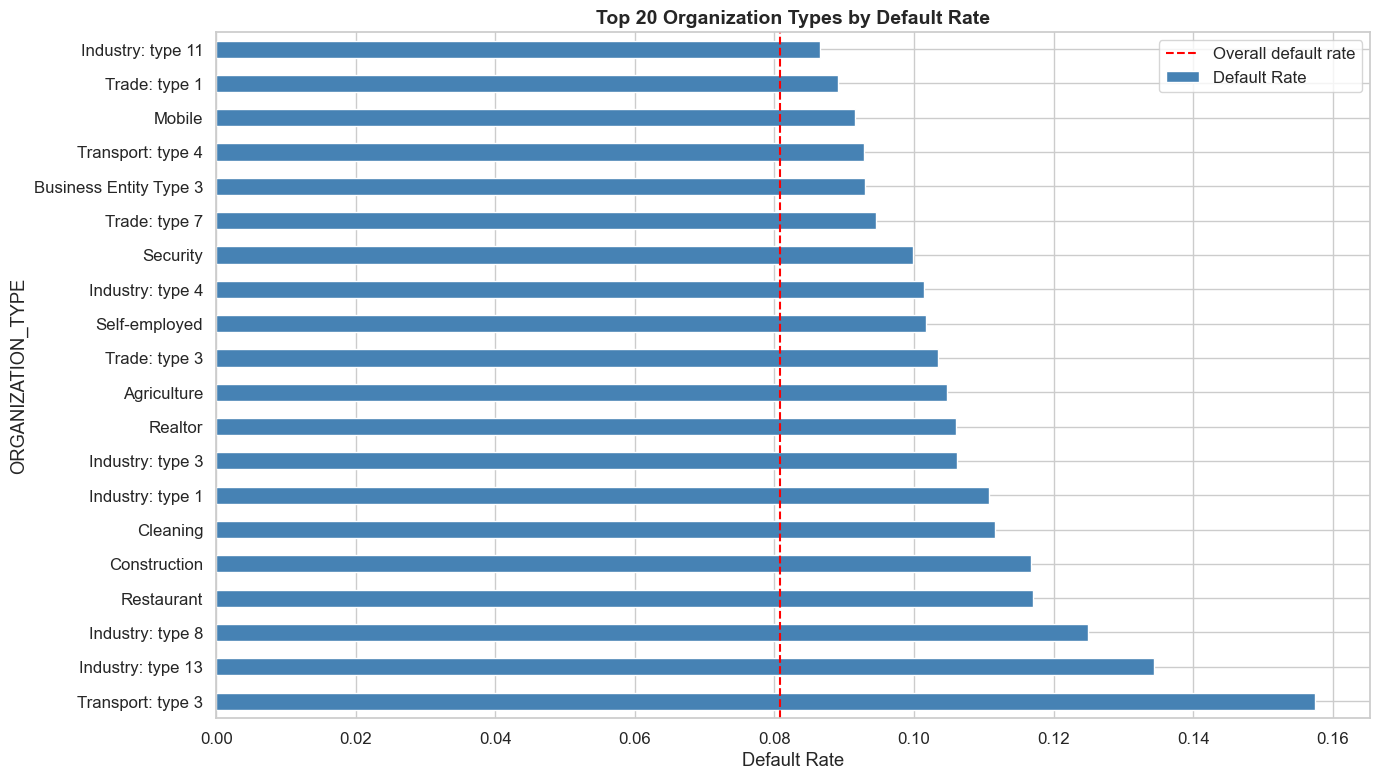


ORGANIZATION_TYPE: 58 unique values

Top 10 by default rate:
                   Default Rate  Count
ORGANIZATION_TYPE                     
Transport: type 3      0.157540   1187
Industry: type 13      0.134328     67
Industry: type 8       0.125000     24
Restaurant             0.117062   1811
Construction           0.116798   6721
Cleaning               0.111538    260
Industry: type 1       0.110683   1039
Industry: type 3       0.106162   3278
Realtor                0.106061    396
Agriculture            0.104727   2454


In [10]:
# ORGANIZATION_TYPE — Top 20 by default rate (too many categories for a single plot)
org_target = train.groupby('ORGANIZATION_TYPE')[target_col].agg(['mean', 'count'])
org_target.columns = ['Default Rate', 'Count']
org_target = org_target.sort_values('Default Rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
org_target['Default Rate'].head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Organization Types by Default Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Default Rate')
ax.axvline(x=train[target_col].mean(), color='red', linestyle='--', label='Overall default rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nORGANIZATION_TYPE: {train["ORGANIZATION_TYPE"].nunique()} unique values')
print('\nTop 10 by default rate:')
print(org_target.head(10).to_string())

---
### 7. External Source Scores — Correlation with TARGET

Correlation with TARGET:
  EXT_SOURCE_1: -0.1553
  EXT_SOURCE_2: -0.1605
  EXT_SOURCE_3: -0.1789


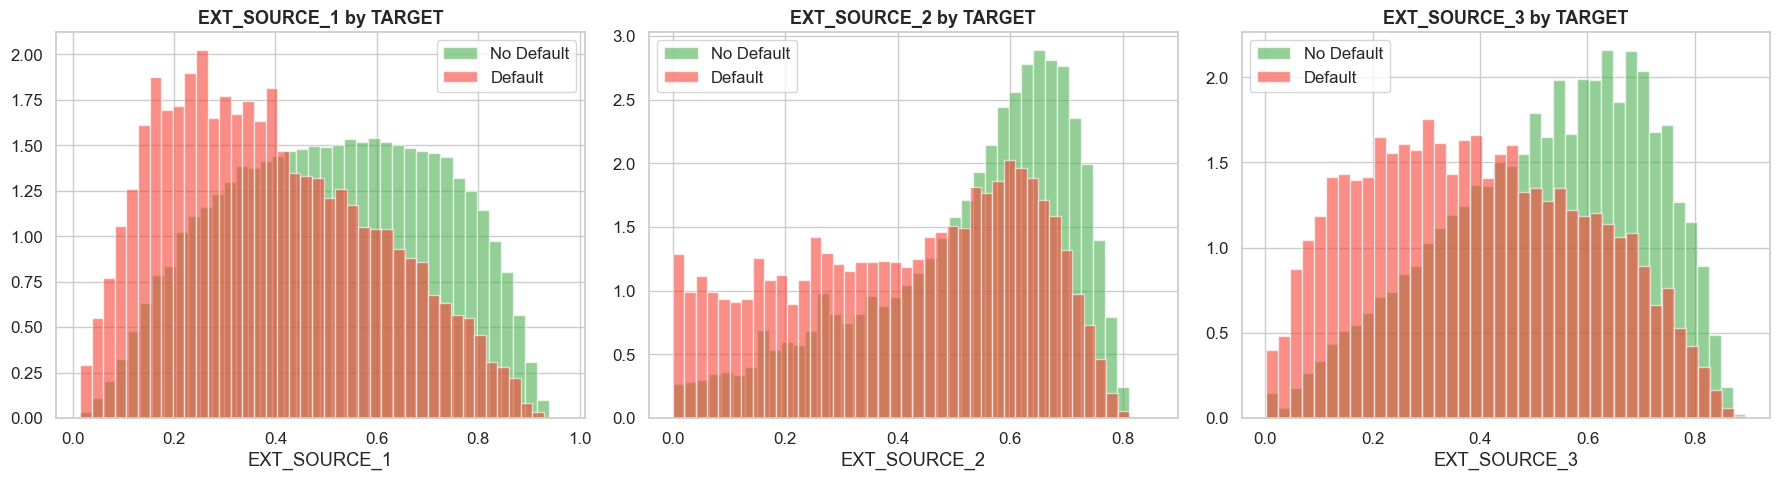

In [11]:
# EXT_SOURCE features are known to be the most predictive in the Home Credit dataset
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('Correlation with TARGET:')
for col in ext_cols:
    corr = train[col].corr(train[target_col])
    print(f'  {col}: {corr:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(ext_cols):
    for target_val, color, label in [(0, '#4CAF50', 'No Default'), (1, '#F44336', 'Default')]:
        subset = train[train[target_col] == target_val][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'{col} by TARGET', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

---
### 8. Correlation Heatmap

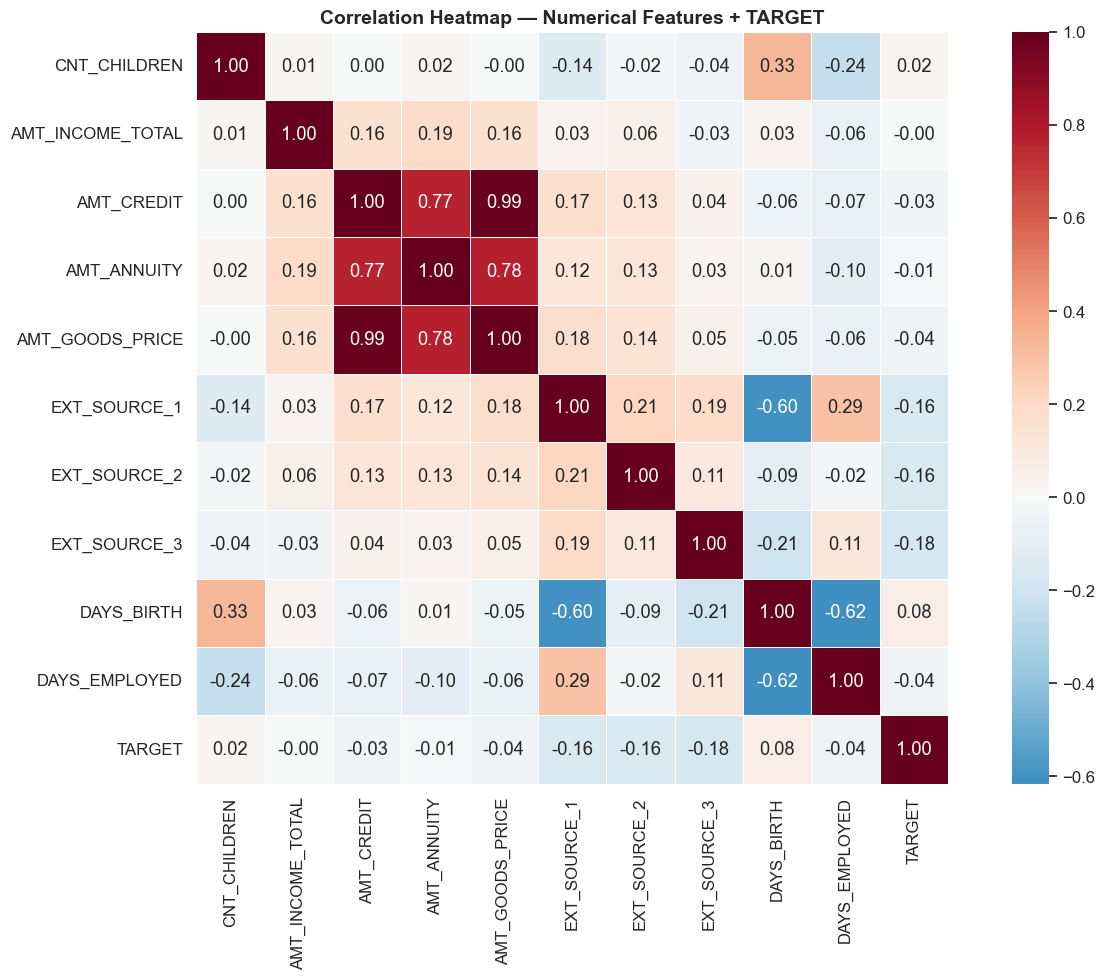

In [12]:
# Correlation of numerical features with TARGET
corr_cols = numerical_features + [target_col]
corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features + TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Top correlations with TARGET
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print('Feature correlations with TARGET (sorted by absolute value):')
for feat, corr in target_corr.items():
    print(f'  {feat:<20} : {corr:+.4f}')

Feature correlations with TARGET (sorted by absolute value):
  EXT_SOURCE_3         : -0.1789
  EXT_SOURCE_2         : -0.1605
  EXT_SOURCE_1         : -0.1553
  DAYS_BIRTH           : +0.0782
  DAYS_EMPLOYED        : -0.0449
  AMT_GOODS_PRICE      : -0.0396
  AMT_CREDIT           : -0.0304
  CNT_CHILDREN         : +0.0192
  AMT_ANNUITY          : -0.0128
  AMT_INCOME_TOTAL     : -0.0040
